# Concrete Fissure Analysis Notebook
This notebook analyzes images of concrete fissures using OpenAI Frontier models and generates a concise summary.

In [12]:

import os
from dotenv import load_dotenv
import openai

# Load your API key from an .env file or environment variable
load_dotenv()
openai.api_key = os.getenv("OPENAI_API_KEY")


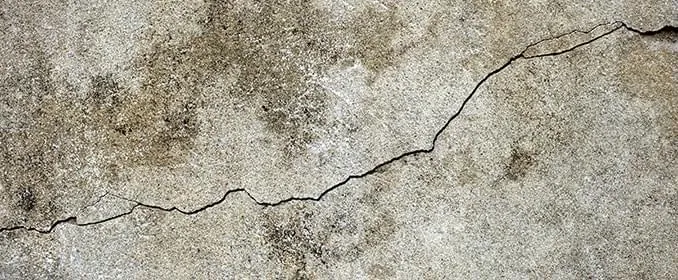

In [13]:

from PIL import Image
import io

def load_image(image_path: str) -> Image.Image:
    """Load an image from the given path."""
    return Image.open(image_path)
load_image("RACHADURA.png")


In [ ]:

import cv2
import numpy as np
import matplotlib.pyplot as plt

def plot_fissures(image_path: str):
    """
    Plota as rachaduras detectadas na imagem de concreto.
    As rachaduras são destacadas em vermelho sobre a imagem original.
    """
    # Carrega a imagem em escala de cinza
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Realça as rachaduras usando Canny
    edges = cv2.Canny(gray, threshold1=50, threshold2=150)
    
    # Cria uma imagem colorida para sobrepor as rachaduras
    fissure_img = img.copy()
    fissure_img[edges != 0] = [255, 0, 0]  # vermelho para rachaduras
    
    # Plota o resultado
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(fissure_img, cv2.COLOR_BGR2RGB))
    plt.title("Rachaduras destacadas em vermelho")
    plt.axis("off")
    plt.show()

# Exemplo de uso:
# plot_fissures("RACHADURA.png")


In [17]:

import base64
def analyze_fissure_image(image_path: str) -> str:
    """Analyze a concrete fissure image and return a summary."""
    image = load_image(image_path)
    buf = io.BytesIO()
    image.save(buf, format="PNG")
    buf.seek(0)
    img_bytes = buf.read()
    img_b64 = base64.b64encode(img_bytes).decode("utf-8")

    # Call the Frontier model (replace model name as needed)
    response = openai.chat.completions.create(
        model="o4-mini",  # or your specific frontier model
        messages=[
            {
                "role": "system",
                "content": "You are a helpful assistant"
            },
            {
                "role": "user",
                "content": "Analyze this concrete fissure image and summarize what is happening.",
                "image": {
                    "mime_type": "image/png",
                    "data": img_b64
                }
            }
        ]
    )
    return response.choices[0].message.content


using system_prompt properly

In [18]:

import base64
def analyze_fissure_image(image_path: str) -> str:
    """Analyze a concrete fissure image and return a summary."""
    image = load_image(image_path)
    buf = io.BytesIO()
    image.save(buf, format="PNG")
    buf.seek(0)
    img_bytes = buf.read()
    img_b64 = base64.b64encode(img_bytes).decode("utf-8")

    # Call the Frontier model (replace model name as needed)
    response = openai.chat.completions.create(
        model="o4-mini",  # or your specific frontier model
        messages=[
            {
  "role": "system",
  "content": """
You are a civil-engineering expert in concrete pathology and nondestructive inspection. When given an image, follow these steps:

1. **Verify** that the photo shows a concrete surface.  
2. **Detect** and **locate** any discontinuities—distinguish between hairline cracks, wide fissures, spalling, voids, or surface stains.  
3. **Classify** the defect:
   - Hairline crack (width < 0.3 mm)
   - Structural fissure (width ≥ 0.3 mm)
   - Spall or delamination
   - Other anomaly (stain, efflorescence, rust streak)
4. **Assess severity** on a simple scale (low / moderate / high) based on width, length, and pattern.  
5. **Suggest likely cause(s)** (e.g., shrinkage, thermal stress, loading) and **recommend next steps** (monitor, sealant, professional inspection).  
6. **Summarize** in 2–3 sentences:  
   - What you saw  
   - Its classification and severity  
   - Immediate recommendation

Be concise, use clear engineering terminology, and assume the user has a basic construction background.
"""
}
,
            {
                "role": "user",
                "content": "Analyze this concrete fissure image and summarize what is happening.",
                "image": {
                    "mime_type": "image/png",
                    "data": img_b64
                }
            }
        ]
    )
    return response.choices[0].message.content


In [19]:

img_path = "RACHADURA.png"
summary = analyze_fissure_image(img_path)
print("Summary of fissure analysis:")
print(summary)


Summary of fissure analysis:
1. Verification: The photo shows a cast‐in‐place concrete surface (likely a wall or slab face).  
2. Detection & Location: There is a single continuous crack running roughly vertically through the concrete with minor edge spalling in a 10–15 cm zone; no staining or rust streaks are evident.  
3. Classification: With a measured width of about 0.5–1.0 mm, this is a structural fissure.  
4. Severity: Moderate – the crack is open enough to admit moisture and is several tens of centimeters long.  
5. Likely Cause & Next Steps:  
   – Cause: Likely drying/shrinkage compounded by thermal cycling or slight load movement.  
   – Next Steps: Mark crack endpoints to monitor growth, clean and epoxy‐inject or seal with a low-viscosity polyurethane, and schedule a structural review if widening continues.  
6. Summary:  
A 0.5–1 mm wide vertical structural fissure with minor spalling is present, rated moderate severity. Recommend monitoring for propagation, then clean and